# RuReviews EDA

Starter notebook for class balance, text length checks, duplicates, and sample inspection.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data import (
    class_distribution,
    duplicated_texts,
    empty_texts,
    get_dataset,
    sample_examples,
    split_to_frame,
    text_length_summary,
)

sns.set_theme(style='whitegrid')

In [10]:
dataset = get_dataset()
train_df = split_to_frame(dataset['train'], clean=True)
val_df = split_to_frame(dataset['validation'], clean=True)
test_df = split_to_frame(dataset['test'], clean=True)

print(dataset)
train_df.head()

DatasetDict({
    train: Dataset({
        features: ['text', 'label_text', 'label', 'id'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['text', 'label_text', 'label', 'id'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'label_text', 'label', 'id'],
        num_rows: 15000
    })
})


,text,label_text,label,id
0,всё пришло спасибо. только немного короче чем ...,positive,2,64971
1,The color of the dress is not the same as in t...,neutral,1,34896
2,"Заказывала белый цвет, пришёл какой то персико...",neutral,1,46253
3,Приятное к телу. Но в бюсте на размер больше. ...,negative,0,19034
4,Не пришла деньги через спор вернули,neutral,1,36063


In [11]:
distribution = class_distribution(train_df)
distribution

,label_text,count,share
0,positive,15000,0.333333
1,neutral,15000,0.333333
2,negative,15000,0.333333


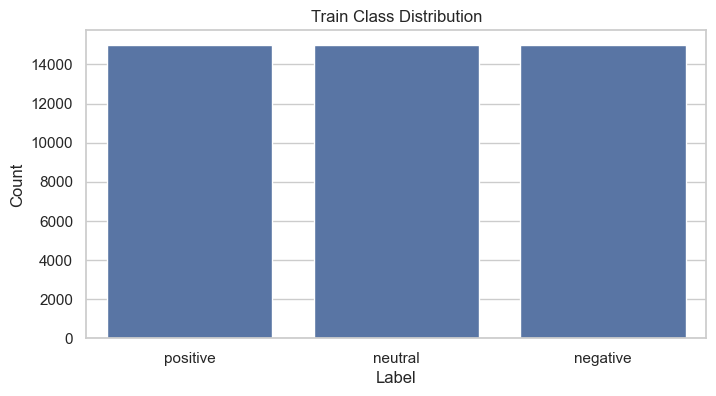

In [12]:
plt.figure(figsize=(8, 4))
sns.barplot(data=distribution, x='label_text', y='count')
plt.title('Train Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [13]:
text_length_summary(train_df)

,length
count,45000.000000
mean,132.822622
std,126.027067
min,1.000000
50%,94.000000
90%,278.000000
95%,375.000000
99%,649.010000
max,1000.000000


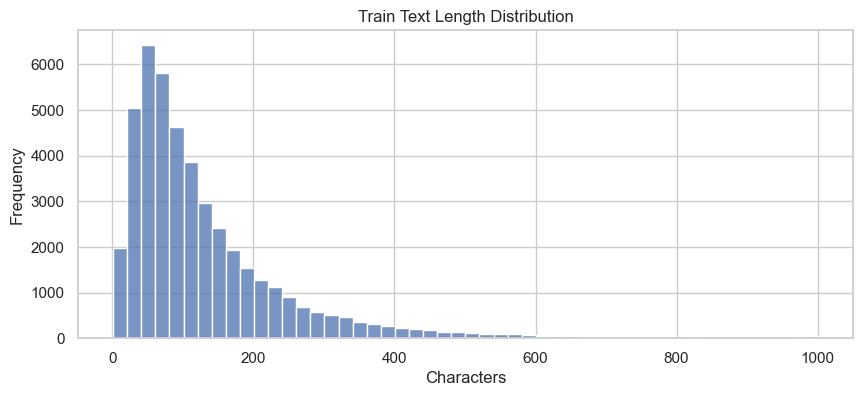

In [14]:
train_df['text_length'] = train_df['text'].str.len()
plt.figure(figsize=(10, 4))
sns.histplot(train_df['text_length'], bins=50)
plt.title('Train Text Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

In [15]:
print('Empty texts:', len(empty_texts(train_df)))
print('Duplicated texts:', len(duplicated_texts(train_df)))

Empty texts: 0
Duplicated texts: 145


In [16]:
sample_examples(train_df, label_value='negative', size=5)[['label_text', 'text']]

,label_text,text
34378,negative,"Леггинсы короткие на рост 170 см, при чем вниз..."
19165,negative,плохо! качество материала ужасное! не похоже н...
39410,negative,Пришло серого цвета .Мне нужна белая .
2504,negative,"Цвет ужас! На картинке голубой, а на самом дел..."
17665,negative,"По неизвестным причинам, товар сначала долго о..."
